In [13]:
# Handling sequential data using CNN wiht 1 D conv
# Data in this case sequential and model prediect a spefic sequance  
# labels encode (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING) to 0-5
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.python.keras.models import Sequential
from tensorflow.python.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
import os

In [14]:
SIGNALS = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z",
]

def load_signals(data_dir, split):
    signals_data = []

    for signal in SIGNALS:
        filename = f"{signal}_{split}.txt"
        filepath = os.path.join(
            data_dir, split, "Inertial Signals", filename
        )
        signals_data.append(np.loadtxt(filepath))

    # shape: (samples, 128, 9)
    return np.stack(signals_data, axis=-1)


def load_labels(data_dir, split):
    path = os.path.join(data_dir, split, f"y_{split}.txt")
    return np.loadtxt(path).astype(int) - 1  # labels: 0–5


In [15]:
DATASET_PATH = "D:/IMPORTANT/ML/DL/8-temporal_CNN/UCI HAR Dataset"

X_train = load_signals(DATASET_PATH, "train")
y_train = load_labels(DATASET_PATH, "train") 

X_test = load_signals(DATASET_PATH, "test")
y_test = load_labels(DATASET_PATH, "test")

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

print(X_train[0].shape)
print(y_train[0])

Train: (7352, 128, 9) (7352,)
Test : (2947, 128, 9) (2947,)
(128, 9)
4


In [16]:
mean = X_train.mean(axis=(0,1), keepdims=True)
std = X_train.std(axis=(0,1), keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_test  = (X_test - mean) / std


In [17]:
model = Sequential([
    Conv1D(64, 3, activation="relu", input_shape=(128, 9)),
    MaxPooling1D(2),

    Conv1D(128, 3, activation="relu",  kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    #tf.keras.backend.batch_normalization(),
    MaxPooling1D(2),

    Conv1D(256, 3, activation="relu",  kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    #tf.keras.backend.batch_normalization(),
    MaxPooling1D(2),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(6, activation="softmax")
])

model.summary()


Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d_3 (Conv1D)            (None, 126, 64)           1792      
_________________________________________________________________
max_pooling1d_3 (MaxPooling1 (None, 63, 64)            0         
_________________________________________________________________
conv1d_4 (Conv1D)            (None, 61, 128)           24704     
_________________________________________________________________
max_pooling1d_4 (MaxPooling1 (None, 30, 128)           0         
_________________________________________________________________
conv1d_5 (Conv1D)            (None, 28, 256)           98560     
_________________________________________________________________
max_pooling1d_5 (MaxPooling1 (None, 14, 256)           0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 3584)             

In [18]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
92/92 [==============================] - 1s 9ms/step - loss: 0.5233 - accuracy: 0.8106 - val_loss: 0.2911 - val_accuracy: 0.9273
Epoch 2/10
92/92 [==============================] - 1s 7ms/step - loss: 0.1387 - accuracy: 0.9560 - val_loss: 0.3160 - val_accuracy: 0.9245
Epoch 3/10
92/92 [==============================] - 1s 7ms/step - loss: 0.1174 - accuracy: 0.9597 - val_loss: 0.3107 - val_accuracy: 0.9361
Epoch 4/10
92/92 [==============================] - 1s 7ms/step - loss: 0.1148 - accuracy: 0.9595 - val_loss: 0.3332 - val_accuracy: 0.9381
Epoch 5/10
92/92 [==============================] - 1s 7ms/step - loss: 0.1104 - accuracy: 0.9558 - val_loss: 0.3854 - val_accuracy: 0.9436
Epoch 6/10
92/92 [==============================] - 1s 7ms/step - loss: 0.0970 - accuracy: 0.9646 - val_loss: 0.3986 - val_accuracy: 0.9375
Epoch 7/10
92/92 [==============================] - 1s 7ms/step - loss: 0.0858 - accuracy: 0.9684 - val_loss: 0.5261 - val_accuracy: 0.9218
Epoch 8/10
92/92 [==

In [19]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")


Test Accuracy: 0.9138


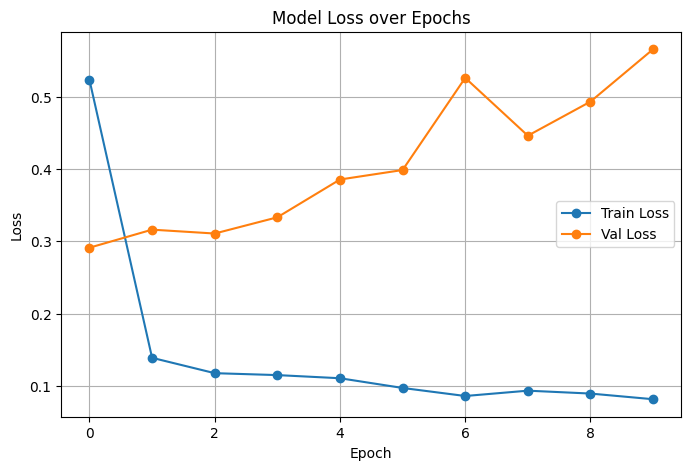

In [20]:

def plot_loss(history):
    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='Train Loss', marker='o')
    plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
    plt.title('Model Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss(history)    